# Phase 5B-0：MPC 可行性边界

本 notebook 只读取已经完成的 69 个冻结 Phase 5A 降阶场景结果，不重新求解 MPC。研究问题是：在相同状态估计误差下，名义 MPC 与知道真实参数的 oracle MPC 是否自身可行，以及哪些 ANN 失败不能归因于模仿误差。

教师可行判据为：真实目标完成、真实物理安全、优化成功率至少 95%，且 fallback 次数为 0。真实边界是 4.20 V、35 ℃、10 A 和每 5 s 最大 2 A 变化；终端真实 SOC 误差容差为 ±0.015。

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'data' / 'phase5b_mpc_feasibility').exists():
    ROOT = ROOT.parent
assert (ROOT / 'data' / 'phase5b_mpc_feasibility').exists(), '请从项目根目录或 notebooks 目录执行'
DATA = ROOT / 'data' / 'phase5b_mpc_feasibility'
METRICS = json.loads((ROOT / 'outputs' / 'metrics' / 'phase5b0_metrics.json').read_text(encoding='utf-8'))
runs = pd.read_csv(DATA / 'controller_run_summary.csv')
table = pd.read_csv(DATA / 'scenario_feasibility_table.csv')
ann = pd.read_csv(ROOT / 'data' / 'phase5a' / 'reduced_stress_summary.csv')
assert len(runs) == 138 and table['scenario_id'].nunique() == 69
assert runs.groupby('scenario_id')['controller'].nunique().eq(2).all()
print(f'读取 {len(runs)} 条教师运行记录，覆盖 {table.scenario_id.nunique()} 个场景。')

读取 138 条教师运行记录，覆盖 69 个场景。


## 1. 教师总体可行性

oracle MPC 只知道真实容量与电热参数，仍使用与名义 MPC 相同的带噪状态估计；因此两者差异用于审计参数失配，而不是构造一个完美传感器上界。

,controller,scenario_count,completion_fraction,physical_safety_fraction,feasible_count,feasible_fraction,mean_solve_time_ms,maximum_solve_time_ms
0,nominal_mpc,69,0.8696,0.0725,5,0.0725,1110.5532,9634.2450
1,oracle_mpc,69,0.8551,0.0145,1,0.0145,1190.3718,10075.4366


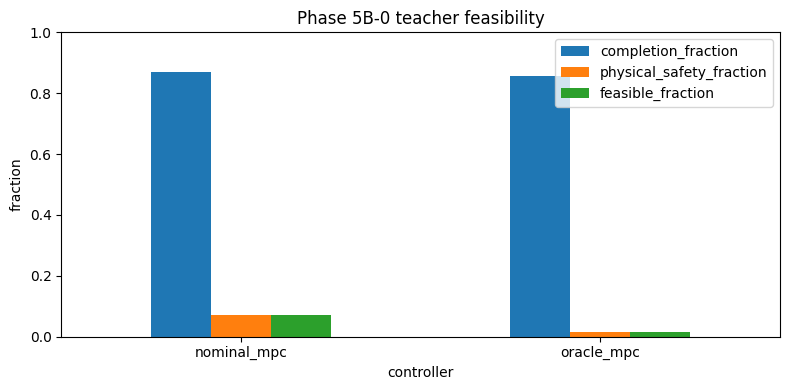

In [2]:
summary = pd.DataFrame(METRICS['controller_summary'])
display(summary[['controller', 'scenario_count', 'completion_fraction', 'physical_safety_fraction', 'feasible_count', 'feasible_fraction', 'mean_solve_time_ms', 'maximum_solve_time_ms']].round(4))
ax = summary.set_index('controller')[['completion_fraction', 'physical_safety_fraction', 'feasible_fraction']].plot.bar(figsize=(8, 4), ylim=(0, 1), rot=0)
ax.set_ylabel('fraction'); ax.set_title('Phase 5B-0 teacher feasibility')
plt.tight_layout()

## 2. 场景分类

`ann_feasible_teachers_failed_unresolved` 不计入 ANN 成功：Phase 5A ANN 使用了安全层，而本阶段教师是无安全层的完整 MPC；两者并非同一控制器契约。

In [3]:
class_counts = table['scenario_class'].value_counts().rename_axis('scenario_class').reset_index(name='scenario_count')
display(class_counts)
display(table[['scenario_id', 'scenario_kind', 'ambient_temperature_c', 'resistance_multiplier', 'heat_capacity_multiplier', 'thermal_resistance_multiplier', 'ann_feasible', 'nominal_mpc_feasible', 'oracle_mpc_feasible', 'scenario_class']].head(12))

,scenario_class,scenario_count
0,teacher_and_ann_infeasible,35
1,ann_feasible_teachers_failed_unresolved,29
2,teacher_and_ann_feasible,5


,scenario_id,scenario_kind,ambient_temperature_c,resistance_multiplier,heat_capacity_multiplier,thermal_resistance_multiplier,ann_feasible,nominal_mpc_feasible,oracle_mpc_feasible,scenario_class
0,corner_cold_resistive,directed_corner,15.000000,1.200000,1.000000,1.000000,True,False,False,ann_feasible_teachers_failed_unresolved
1,corner_hot_resistive_optimistic,directed_corner,30.000000,1.200000,0.850000,1.200000,False,False,False,teacher_and_ann_infeasible
2,corner_observer_optimistic,directed_corner,25.000000,1.000000,1.000000,1.000000,True,False,False,ann_feasible_teachers_failed_unresolved
3,corner_observer_pessimistic,directed_corner,25.000000,1.000000,1.000000,1.000000,False,False,False,teacher_and_ann_infeasible
4,lhs_000,latin_hypercube,17.197093,1.105886,0.921000,0.913443,True,False,False,ann_feasible_teachers_failed_unresolved
5,lhs_001,latin_hypercube,22.460929,1.066002,0.884694,1.079419,False,False,False,teacher_and_ann_infeasible
6,lhs_002,latin_hypercube,28.712054,0.805594,1.112614,0.844805,False,False,False,teacher_and_ann_infeasible
7,lhs_003,latin_hypercube,15.674735,1.108129,1.127340,1.146085,True,False,False,ann_feasible_teachers_failed_unresolved
8,lhs_004,latin_hypercube,24.614164,0.829915,0.870717,0.979650,True,False,False,ann_feasible_teachers_failed_unresolved
9,lhs_005,latin_hypercube,23.421211,0.924641,0.916609,0.857490,False,False,False,teacher_and_ann_infeasible


## 3. 教师可行掩码与约束激活

后续 ANN 训练应优先使用名义教师可行掩码；oracle 结果用于解释参数失配，不替代真实可获得的名义教师。

In [4]:
mask = pd.read_csv(DATA / 'teacher_feasible_scenario_mask.csv')
activity = pd.read_csv(DATA / 'teacher_constraint_activity.csv')
print('名义教师可行场景数:', int(mask['teacher_feasible_for_ann_evaluation'].sum()))
display(mask[mask['teacher_feasible_for_ann_evaluation']].sort_values('scenario_id'))
display(activity.round(4))

名义教师可行场景数: 5


,scenario_id,nominal_mpc_feasible,oracle_mpc_feasible,scenario_class,teacher_feasible_for_ann_evaluation
12,lhs_008,True,False,teacher_and_ann_feasible,True
16,lhs_012,True,False,teacher_and_ann_feasible,True
33,lhs_029,True,False,teacher_and_ann_feasible,True
60,lhs_056,True,False,teacher_and_ann_feasible,True
68,nominal,True,True,teacher_and_ann_feasible,True


,controller,active_voltage_constraint_fraction,active_temperature_constraint_fraction,active_current_upper_constraint_fraction,active_current_change_constraint_fraction
0,nominal_mpc,0.3576,0.7489,0.0282,0.2596
1,oracle_mpc,0.3624,0.7520,0.0290,0.2690


## 4. 代表轨迹

优先画名义场景、教师与 ANN 都可行场景，以及 unresolved 场景各一条。轨迹文件来自已保存的 MPC 历史，不会触发重新仿真。

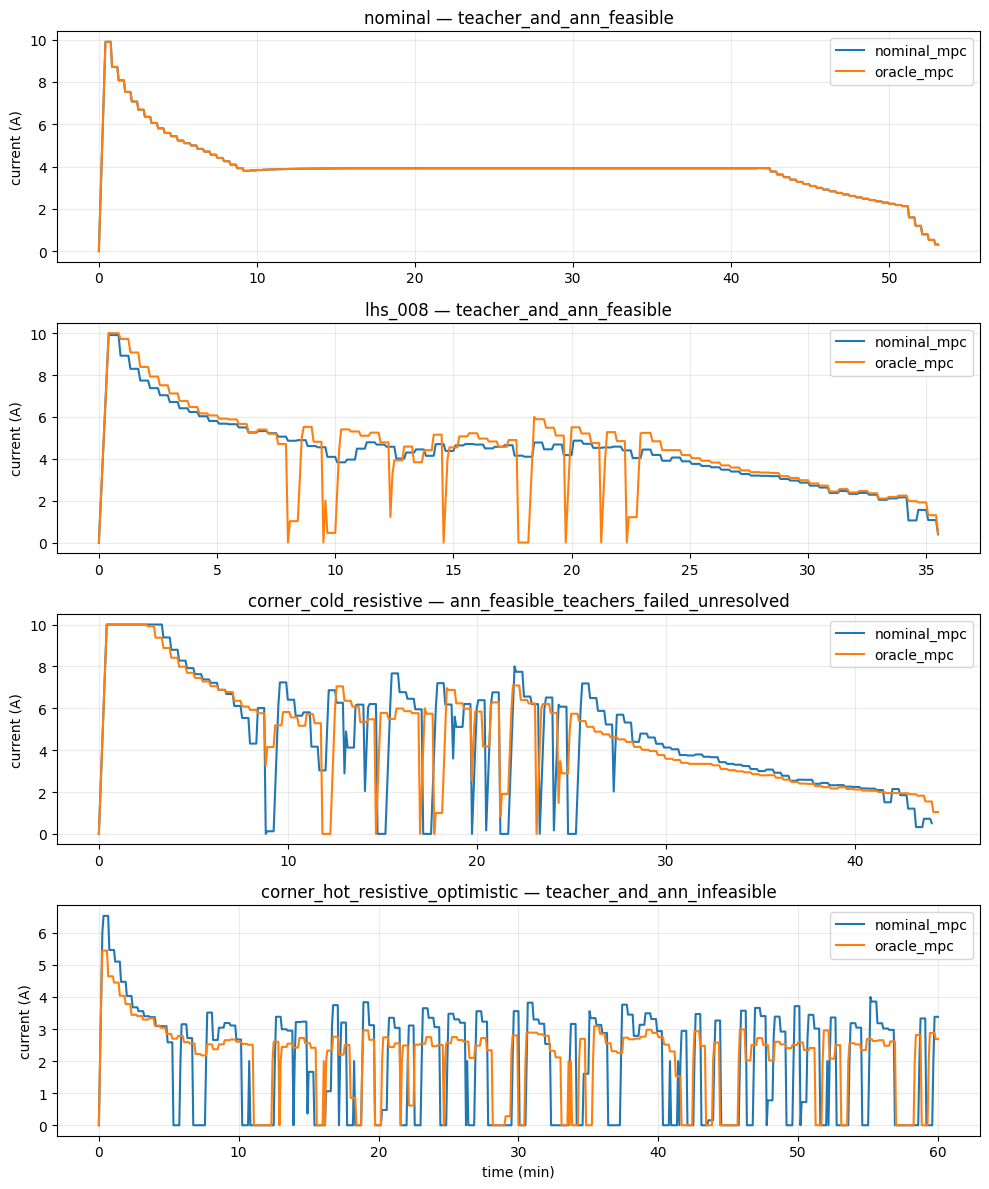

In [5]:
candidate_ids = ['nominal']
for label in ['teacher_and_ann_feasible', 'ann_feasible_teachers_failed_unresolved', 'teacher_and_ann_infeasible']:
    values = table.loc[table['scenario_class'].eq(label), 'scenario_id'].tolist()
    if values:
        candidate_ids.append(values[0])
candidate_ids = list(dict.fromkeys(candidate_ids))
fig, axes = plt.subplots(len(candidate_ids), 1, figsize=(10, 3.0 * len(candidate_ids)), sharex=False)
if len(candidate_ids) == 1: axes = [axes]
for ax, scenario_id in zip(axes, candidate_ids):
    for controller, color in [('nominal_mpc', 'tab:blue'), ('oracle_mpc', 'tab:orange')]:
        frame = pd.read_csv(DATA / 'trajectories' / f'{scenario_id}__{controller}.csv')
        ax.plot(frame['time_s'] / 60, frame['charge_current_a'], label=controller, color=color)
    row = table.loc[table['scenario_id'].eq(scenario_id)].iloc[0]
    ax.set_title(f"{scenario_id} — {row['scenario_class']}")
    ax.set_ylabel('current (A)'); ax.grid(alpha=0.25); ax.legend()
axes[-1].set_xlabel('time (min)')
plt.tight_layout()

## 5. 结论与下一步

本阶段证明当前 Phase 5A 压力域对无安全层完整 MPC 教师过于苛刻：名义教师完整可行率仅 5/69，oracle 仅 1/69。下一步不应把所有 ANN 失败都归因于模仿误差，而应先以名义教师可行掩码建立 Phase 5B-1 数据域，并研究 ANN 候选、约束检查、有限迭代 MPC 修正和必要时完整回退的混合控制器。Phase 5B-0 没有运行 DFN 锚点、跨电池实验或更换电池。

In [6]:
result = {
    'controller_records': len(runs),
    'scenario_count': int(table.scenario_id.nunique()),
    'nominal_teacher_feasible_count': int(table.nominal_mpc_feasible.sum()),
    'oracle_teacher_feasible_count': int(table.oracle_mpc_feasible.sum()),
    'unresolved_count': int((table.scenario_class == 'ann_feasible_teachers_failed_unresolved').sum()),
    'next_stage': 'Phase 5B-1 constrained ANN-MPC hybrid design',
}
result

{'controller_records': 138,
 'scenario_count': 69,
 'nominal_teacher_feasible_count': 5,
 'oracle_teacher_feasible_count': 1,
 'unresolved_count': 29,
 'next_stage': 'Phase 5B-1 constrained ANN-MPC hybrid design'}